### [**tslearn** for Time Series Analysis](https://medium.com/@kyle-t-jones/tslearn-for-time-series-analysis-with-python-237b5139c67e)

`tslearn` is a purpose-built machine learning library for time-series data. It ships with utilities for preprocessing, clustering, classification, and regression that handle both univariate and multivariate sequences. Its standout features are advanced distance measures — such as Dynamic Time Warping (DTW) — and algorithms tailored to time-series structure.

In [1]:
!pip install -q tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.7/372.7 kB 8.1 MB/s eta 0:00:00


In [2]:
import numpy as np

# Three sequences, five time steps, one feature
data = np.array([
    [[1], [2], [3], [4], [5]],
    [[2], [3], [4], [5], [6]],
    [[3], [4], [5], [6], [7]],
])
print(data.shape)

(3, 5, 1)


In [3]:
from tslearn.preprocessing import TimeSeriesResampler
resampler = TimeSeriesResampler(sz=10)
resampled = resampler.fit_transform(data)
print(resampled.shape)

(3, 10, 1)


In [4]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

X = np.random.rand(200, 50, 1)
y = np.random.randint(0, 2, size=200)

# Chronological train/test split (first 80% train, last 20% test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = TimeSeriesScalerMeanVariance()
scaler.fit(X_train)           # learn scaling on train portion only

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    TimeSeriesScalerMeanVariance(),
    # downstream estimator (added later)
)

#### K-Shape

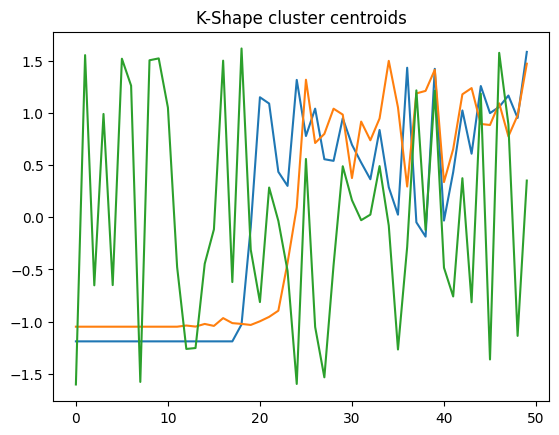

In [5]:
from tslearn.clustering import KShape
import matplotlib.pyplot as plt

X = np.random.rand(100, 50, 1)

model = KShape(n_clusters=3, random_state=0)
labels = model.fit_predict(X)

for centroid in model.cluster_centers_:
    plt.plot(centroid.ravel())

plt.title("K-Shape cluster centroids")
plt.show()

#### DTW-based K-Means

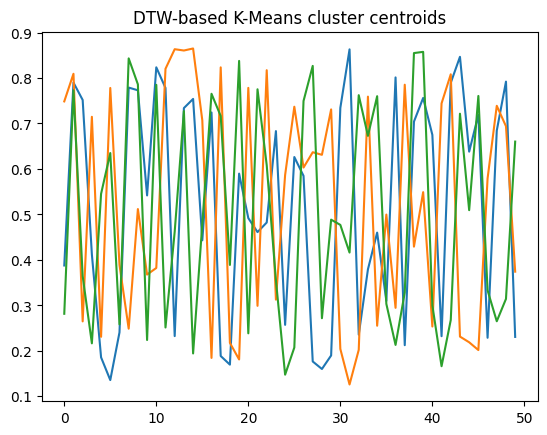

In [6]:
from tslearn.clustering import TimeSeriesKMeans

dtw_model = TimeSeriesKMeans(
    n_clusters=3,
    metric="dtw",
    random_state=0,
)
labels = dtw_model.fit_predict(X)

for centroid in dtw_model.cluster_centers_:
    plt.plot(centroid.ravel())
plt.title("DTW-based K-Means cluster centroids")
plt.show()

#### Classification with Leakage-Safe Workflow

In [7]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

X = np.random.rand(200, 50, 1)
y = np.random.randint(0, 2, size=200)
clf = make_pipeline(
    TimeSeriesScalerMeanVariance(),
    KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="dtw"),
)
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(clf, X, y, cv=tscv)
print(f"Mean CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

# Optional: inspect the most recent fold as a hold-out
train_idx, test_idx = list(tscv.split(X))[-1]
clf.fit(X[train_idx], y[train_idx])
print(f"Hold-out accuracy: {clf.score(X[test_idx], y[test_idx]):.2f}")

Mean CV accuracy: 0.57 ± 0.07
Hold-out accuracy: 0.55


#### Measuring Similarity with DTW

In [8]:
from tslearn.metrics import dtw
ts1 = np.array([[1], [2], [3], [4], [5]])
ts2 = np.array([[2], [3], [4], [5], [6]])
print(f"DTW distance: {dtw(ts1, ts2):.2f}")

DTW distance: 1.41


#### Feature Extraction via SAX

In [9]:
from tslearn.piecewise import SymbolicAggregateApproximation
sax = SymbolicAggregateApproximation(
    n_segments=5,
    alphabet_size_avg=3,
)
X_sax = sax.fit_transform(X)
print(X_sax[:2])

[[[2]
  [2]
  [1]
  [2]
  [1]]

 [[2]
  [2]
  [1]
  [2]
  [2]]]
